Part A

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate some sample data
# Creating data points that roughly follow a quadratic curve
np.random.seed(0)
x = np.linspace(-5, 5, 50) # 50 points between -5 and 5
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10 # y = 2x^2 + 3x + some noise

#Step 2: Linear Least Squares
A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
y_linear = m * x + c

In [31]:
# Step 3: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Step 4: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
y_polynomial = polynomial(x)

Polynomial Coefficients:  [-0.06652428  2.09218103  2.62641665  0.60606342]


In [32]:
# Step 5: Mean Squared Error (MSE)
def compute_metrics(y_true, y_pred):
    mse = np.mean((y - y_pred)**2)
    print(f'Mean Squared Error: {mse:.4f}')
    # R-squared value
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    return mse, r_squared

mse_linear, rsquared_linear = compute_metrics(y, y_linear)
mse_polynomial, rsquared_polynomial = compute_metrics(y, y_polynomial)

Mean Squared Error: 372.0052
Mean Squared Error: 107.1117


In [33]:
# Step 6: Results
print("LINEAR FIT:")
print(f"Slope: {m:.4f}, Intercept: {c:.4f}")
print(f"MSE: {mse_linear:.4f}, R^2: {rsquared_linear:.4f}\n")

print("POLYNOMIAL FIT (degree 3):")
print(f"Coefficients: {coefficients}")
print(f"MSE: {mse_polynomial:.4f}, R^2: {rsquared_polynomial:.4f}\n")

LINEAR FIT:
Slope: 1.5884, Intercept: 18.7525
MSE: 372.0052, R^2: 0.0556

POLYNOMIAL FIT (degree 3):
Coefficients: [-0.06652428  2.09218103  2.62641665  0.60606342]
MSE: 107.1117, R^2: 0.7281



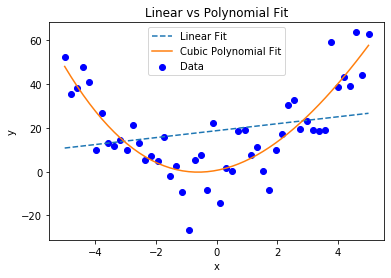

In [34]:
# Step 7: Plot
import matplotlib.pyplot as plt

plt.scatter(x, y, label="Data", color='blue')
plt.plot(x, y_linear, label="Linear Fit", linestyle='--')
plt.plot(x, y_polynomial, label="Cubic Polynomial Fit")

plt.title("Linear vs Polynomial Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Part B

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate some sample data
# Creating data points that roughly follow a quadratic curve
np.random.seed(0)
x = np.linspace(-5, 5, 50) # 50 points between -5 and 5
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10 # y = 2x^2 + 3x + some noise

#Step 2: Linear Least Squares
A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
y_linear = m * x + c

In [36]:
# Step 3: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Step 4: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
y_polynomial = polynomial(x)

Polynomial Coefficients:  [-0.06652428  2.09218103  2.62641665  0.60606342]


In [37]:
# Step 5: Mean Squared Error (MSE)
def compute_metrics(y_true, y_pred):
    mse = np.mean((y - y_pred)**2)
    print(f'Mean Squared Error: {mse:.4f}')
    # R-squared value
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    return mse, r_squared

mse_linear, rsquared_linear = compute_metrics(y, y_linear)

Mean Squared Error: 372.0052


In [38]:
# Step 6: Polynomial Analysis
start_degree = 3
max_degree = 15  #cap
results = []
models = {}
for degree in range(1, max_degree + 1):
    coefficients = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coefficients)
    y_polynomial = polynomial(x)

    mse_poly, rsquared_poly = compute_metrics(y, y_polynomial)

    results.append((degree, mse_poly, rsquared_poly))
    models[degree] = (coefficients, polynomial, y_polynomial)


Mean Squared Error: 372.0052
Mean Squared Error: 108.8860
Mean Squared Error: 107.1117
Mean Squared Error: 106.6460
Mean Squared Error: 106.5613
Mean Squared Error: 106.5081
Mean Squared Error: 105.9831
Mean Squared Error: 105.6799
Mean Squared Error: 103.5451
Mean Squared Error: 103.4718
Mean Squared Error: 102.2765
Mean Squared Error: 90.9595
Mean Squared Error: 90.8931
Mean Squared Error: 90.6738
Mean Squared Error: 86.1701


In [39]:
# Step 7: Results
print("LINEAR FIT:")
print(f"Slope: {m:.4f}, Intercept: {c:.4f}")
print(f"MSE: {mse_linear:.4f}, R^2: {rsquared_linear:.4f}\n")

print("POLYFIT SWEEP RESULTS:")
for degree, mse_poly, rsq_poly in results:
    print(f"Degree {degree:2d} -> MSE: {mse_poly:10.4f}, R^2: {rsq_poly:8.4f}")

LINEAR FIT:
Slope: 1.5884, Intercept: 18.7525
MSE: 372.0052, R^2: 0.0556

POLYFIT SWEEP RESULTS:
Degree  1 -> MSE:   372.0052, R^2:   0.0556
Degree  2 -> MSE:   108.8860, R^2:   0.7236
Degree  3 -> MSE:   107.1117, R^2:   0.7281
Degree  4 -> MSE:   106.6460, R^2:   0.7292
Degree  5 -> MSE:   106.5613, R^2:   0.7295
Degree  6 -> MSE:   106.5081, R^2:   0.7296
Degree  7 -> MSE:   105.9831, R^2:   0.7309
Degree  8 -> MSE:   105.6799, R^2:   0.7317
Degree  9 -> MSE:   103.5451, R^2:   0.7371
Degree 10 -> MSE:   103.4718, R^2:   0.7373
Degree 11 -> MSE:   102.2765, R^2:   0.7403
Degree 12 -> MSE:    90.9595, R^2:   0.7691
Degree 13 -> MSE:    90.8931, R^2:   0.7692
Degree 14 -> MSE:    90.6738, R^2:   0.7698
Degree 15 -> MSE:    86.1701, R^2:   0.7812


Part C

In [40]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
x = np.linspace(-5, 5, 50) # 50 points between -5 and 5
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10 # y = 2x^2 + 3x + some noise

In [41]:
#Vandermonde matrix
degree = 3
V = np.vander(x, N=degree+1, increasing=True)
coefficients_vander = np.linalg.lstsq(V, y, rcond=None)[0]
y_vander = V @ coefficients_vander

#Compare vander to numpy ployfit
coefficients_polyfit = np.polyfit(x, y, degree)
poly = np.poly1d(coefficients_polyfit)
y_polyfit = poly(x)

In [42]:
def compute_metrics(y_true, y_pred):
    mse = np.mean((y - y_pred)**2)
    print(f'Mean Squared Error: {mse:.4f}')
    # R-squared value
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    return mse, r_squared
mse_vander, rsq_vander = compute_metrics(y, y_vander)
mse_polyfit, rsq_polyfit = compute_metrics(y, y_polyfit)

Mean Squared Error: 107.1117
Mean Squared Error: 107.1117


In [43]:
#Results
print("VANDERMONDE FIT (degree 3):")
print(f"Coefficients (a0..a3): {coefficients_vander}")
print(f"MSE: {mse_vander:.4f}, R^2: {rsq_vander:.4f}\n")

print("POLYFIT FIT (degree 3):")
print(f"Coefficients (a3..a0): {coefficients_polyfit}")
print(f"MSE: {mse_polyfit:.4f}, R^2: {rsq_polyfit:.4f}\n")

VANDERMONDE FIT (degree 3):
Coefficients (a0..a3): [ 0.60606342  2.62641665  2.09218103 -0.06652428]
MSE: 107.1117, R^2: 0.7281

POLYFIT FIT (degree 3):
Coefficients (a3..a0): [-0.06652428  2.09218103  2.62641665  0.60606342]
MSE: 107.1117, R^2: 0.7281



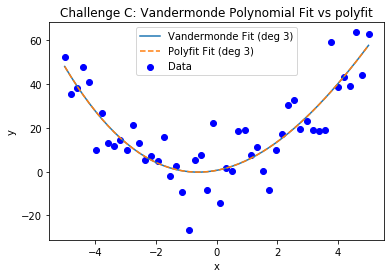

In [44]:
#Plot
plt.scatter(x, y, label="Data", color='blue')
plt.plot(x, y_vander, label="Vandermonde Fit (deg 3)")
plt.plot(x, y_polyfit, label="Polyfit Fit (deg 3)", linestyle="--")

plt.title("Challenge C: Vandermonde Polynomial Fit vs polyfit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()